In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import cv2
from matplotlib import pyplot as plt
import os
#---------
import matplotlib.pyplot as plt
from skimage.morphology import disk, binary_erosion, binary_dilation, binary_opening, binary_closing
import numpy as np
from scipy.ndimage import binary_fill_holes
#---------
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
#---------
from scipy.ndimage import distance_transform_edt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label, regionprops
from skimage import color
from skimage.io import imread
from skimage import filters, measure
#---------

In [ ]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))
img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Saving valve_ID98.png to valve_ID98.png


#In the crop section, you'll need to manually adjust the dimensions
#Try to get the image to be as closely cropped to the leaflets as you can for the best results

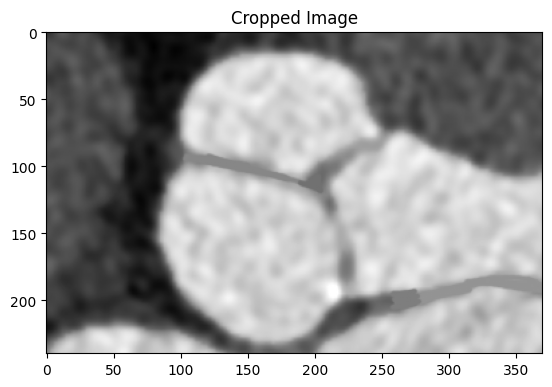

In [ ]:
#CROP IMAGE
crop = gray[530:770, 790:1160]
plt.imshow(crop, cmap='gray')
plt.title('Cropped Image')
plt.show()

In [ ]:
#DPI


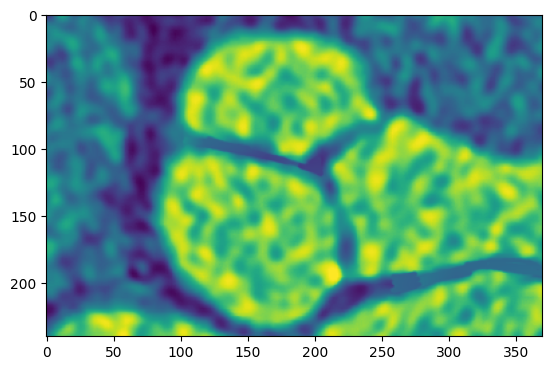

In [ ]:
#Enhancing Contrast
CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhance = CLAHE.apply(crop)

#Enhanced Image
plt.imshow(enhance)


In [ ]:
#Bilateral Filter
denoise = cv2.bilateralFilter(enhance, d=9, sigmaColor=75, sigmaSpace=75)

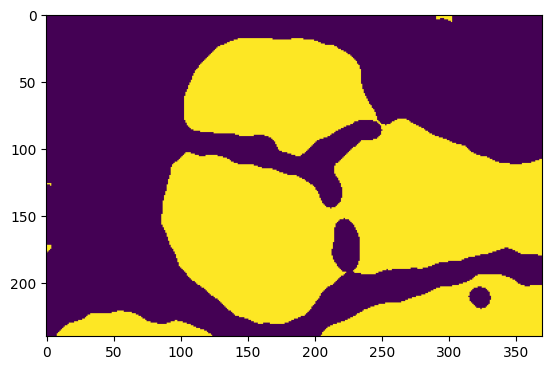

In [ ]:
#Binary Mask
threshold = filters.threshold_otsu(denoise)
binary = denoise <= threshold

#Binary Dilation
dilation = binary_dilation(binary, disk(3))

#Binary Opening
opened = binary_opening(dilation, disk(7))

#Fill holes
filled = binary_fill_holes(opened)

#Invert
_, inv_filled = cv2.threshold(filled.astype(np.uint8) * 255, 127, 255, cv2.THRESH_BINARY_INV)
plt.imshow(inv_filled)

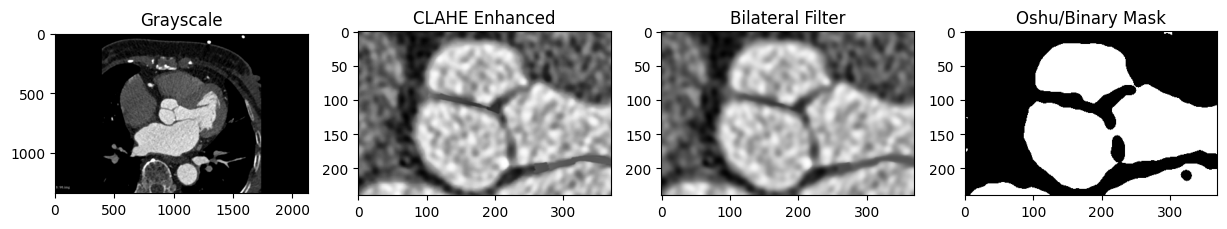

In [ ]:
#Checking image after changes, running this box is optional
fig, axes = plt.subplots(1,4, figsize=(15,5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[1].imshow(enhance, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
axes[2].imshow(denoise, cmap='gray')
axes[2].set_title('Bilateral Filter')
axes[3].imshow(inv_filled, cmap='gray')
axes[3].set_title("Oshu/Binary Mask")
plt.show()

In [ ]:
#Crop the image AGAIN and use some threshold or wtv
#Use pixels for Kmeans (masked by threshold)
#Use Kmeans to put a leaflet as one cluster each
#Use edge detection to measure length of leaflets
#I think ALSO find the area of the leaflets??
#Also print how asymmetrical the leaflets are to each other

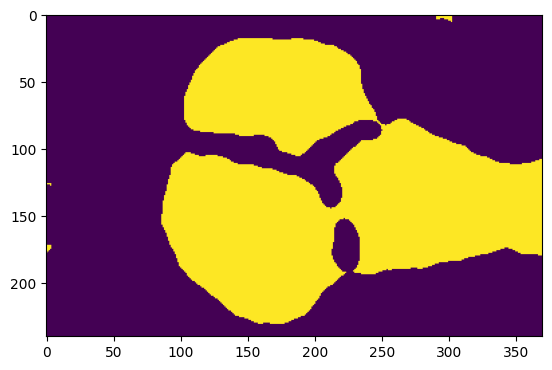

In [ ]:
from skimage.measure import label, regionprops

height, width = inv_filled.shape

labels = label(inv_filled, connectivity=2)
inv_filled_modified = inv_filled.copy()

#Loop to check which pixels marked 1 are touching the bottom of the box
for region in regionprops(labels):
    min_row, min_col, max_row, max_col = region.bbox

    if max_row == height:
        for coords in region.coords:
            inv_filled_modified[coords[0], coords[1]] = 0

plt.imshow(inv_filled_modified)

In [ ]:
#Flatten image and mask
#Assuming K-means is to be applied to the 'denoise' image, masked by 'filled'
pixels = denoise.reshape((-1, 1)) #Reshape denoise for K-means (single channel)
mask_flat = inv_filled_modified.astype(bool).flatten() #True = leaflet pixel, False = background

#Select masked pixels
selected_pixels = pixels[mask_flat] #Select ONLY pixels where mask is True (leaflet pixels)
selected_pixels = np.float32(selected_pixels)

max_iter = 100 #Define max_iter for K-means criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, max_iter, 1.0)

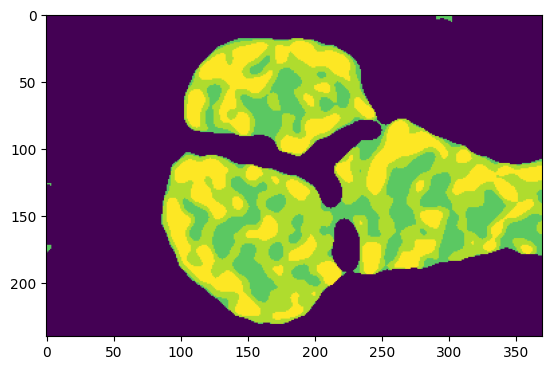

In [ ]:
#This cell is not important to run, but will be kept to show thought process behind creating tool
#Use Kmeans to put a leaflet as one cluster each

_, labels_km, centers = cv2.kmeans(selected_pixels, 3, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)

#Replace masked pixels with cluster colors
segmented_pixels = centers[labels_km.flatten()]
output_pixels = np.zeros_like(pixels) # background becomes 0
output_pixels[mask_flat] = segmented_pixels

segmented_image = output_pixels.reshape(denoise.shape)

plt.imshow(segmented_image)

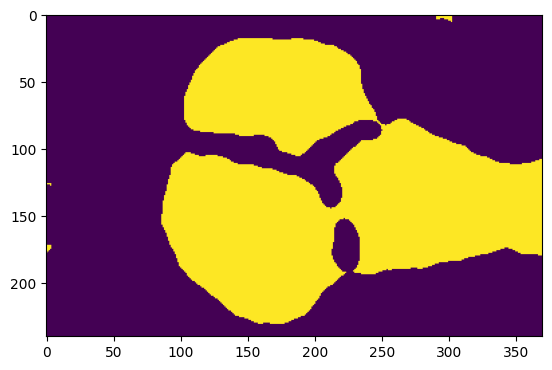

In [ ]:
#need to remove the bottom part of unimportant stuff from binary mask!
from skimage.measure import label, regionprops

height, width = inv_filled.shape

labels = label(inv_filled, connectivity=2)
inv_filled_modified = inv_filled.copy()

#Loop to check which pixels marked 1 are touching the bottom of the box
for region in regionprops(labels):
    min_row, min_col, max_row, max_col = region.bbox

    if max_row == height:
        for coords in region.coords:
            inv_filled_modified[coords[0], coords[1]] = 0

plt.imshow(inv_filled_modified)

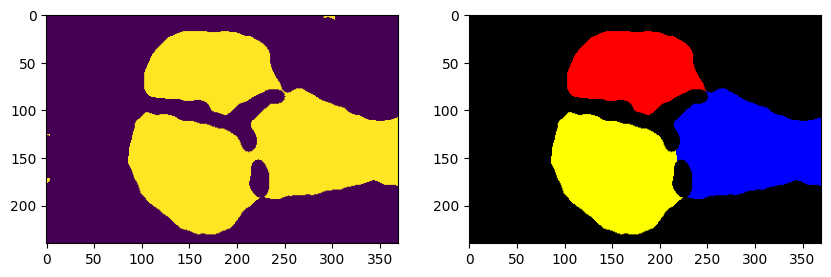

In [ ]:
##Program finds widest point of each leaflet as a seed and has it grow outward until it reaches a boundary
distance = distance_transform_edt(inv_filled_modified)

#Coords finds the coordinates of the boundary for each leaflet
coords = peak_local_max(distance, min_distance=25, labels=inv_filled_modified) #min_distance is the boundary set
peak_mask = np.zeros(distance.shape, dtype=bool)
peak_mask[tuple(coords.T)] = True
markers = label(peak_mask)
leaflet_labels = watershed(-distance, markers, mask=inv_filled_modified)

#Highlighting and showing leaflets in diff colors
colored = color.label2rgb(leaflet_labels, bg_label=0, bg_color=(0, 0, 0))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(inv_filled_modified)
axes[1].imshow(colored)

In [ ]:
#Labels each leaflet in the scan (as shown in next cell)
for region in regionprops(leaflet_labels):
    y, x = region.centroid
    axes[1].text(x, y, str(region.label), color='white', fontsize=12,
                 ha='center', va='center', weight='bold')

Leaflet 1: area=8967px  perimeter=401.7px  major_axis=141.4px
Leaflet 2: area=12804px  perimeter=516.7px  major_axis=163.7px
Leaflet 3: area=12473px  perimeter=450.5px  major_axis=146.9px


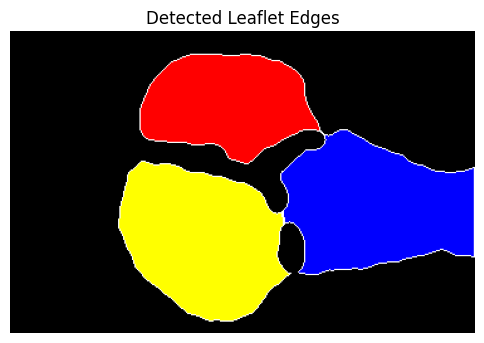

In [ ]:
#Edge detection
#For this, I've included data such as area, perimeter, and major axises for each leaflet
leaflet_data = []
for region in regionprops(leaflet_labels):
    single_leaflet = (leaflet_labels == region.label).astype(np.uint8)
    contours, _ = cv2.findContours(single_leaflet, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour = max(contours, key=cv2.contourArea)

 #place in this format because those lines were getting long...
 #Taken from that research paper
    leaflet_data.append({
        'label': region.label,
        'area_px': region.area,
        'perimeter_px': cv2.arcLength(contour, closed=True),
        'major_axis_length_px': region.axis_major_length,
        'minor_axis_length_px': region.axis_minor_length,
        'centroid': region.centroid,
        'contour': contour,
    })

for d in leaflet_data:
    print(f"Leaflet {d['label']}: area={d['area_px']:.0f}px  "
          f"perimeter={d['perimeter_px']:.1f}px  "
          f"major_axis={d['major_axis_length_px']:.1f}px"
          )

edge_overlay = (colored * 255).astype(np.uint8).copy()
for d in leaflet_data:
    cv2.drawContours(edge_overlay, [d['contour']], -1, (255, 255, 255), 1)
plt.figure(figsize=(6, 6))
plt.imshow(edge_overlay)
plt.title('Detected Leaflet Edges')
plt.axis('off')
plt.show()


In [ ]:
#Convert pixels to cm
#PPF described: pixel edge = 0.0338 cm/each pixel area = 0.001142 cm^2
pixel_edge = 0.0338
pixel_area = 0.001142

areas = np.array([d['area_px'] for d in leaflet_data], dtype=float) * pixel_area
lengths = np.array([d['major_axis_length_px'] for d in leaflet_data], dtype=float) * pixel_edge

print(f"Area mean: {(areas.mean()):.4f} cm^2 (std: {(areas.std()):.4f} cm^2)")
print(f"Area Asymmetry Rate: {float(areas.std() / areas.mean()):.3f}") #0 meaning perfectly symmetrical and 1 meaning TOTALLY NOT
print(f"Area max/min ratio: {areas.max()/areas.min():.3f}")
print(f"Length coefficient of variation: {float(lengths.std()/lengths.mean()):.3f}")

print("\nPairwise area differences:")
n = len(leaflet_data)
for i in range(n):
    for j in range(i + 1, n):
        diff_pct = abs(areas[i]-areas[j]) / max(areas[i], areas[j]) * 100
        print(f"Leaflet {leaflet_data[i]['label']} vs " f"{leaflet_data[j]['label']}: {diff_pct:.1f}% area difference")


Area mean: 13.0355 cm^2 (std: 1.9825 cm^2)
Area Asymmetry Rate: 0.152
Area max/min ratio: 1.428
Length coefficient of variation: 0.063

Pairwise area differences:
Leaflet 1 vs 2: 30.0% area difference
Leaflet 1 vs 3: 28.1% area difference
Leaflet 2 vs 3: 2.6% area difference
